<a href="https://colab.research.google.com/github/L1ght6/LabsKSVD/blob/main/%D0%93%D0%BE%D1%80%D0%B0%D0%9B%D0%A03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 3 КСВД Гора ФІТ3-9

---
https://colab.research.google.com/drive/1WUDyk38zp1O32L_d-3KtYrGLED1ROQJO?usp=sharing


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження датасету
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')

# Очищення даних: перетворення стовпця 'streams' у числовий формат
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# Видалення рядків з порожніми значеннями у 'streams'
df = df.dropna(subset=['streams'])

Завдання 1. Горизонтальна стовпчикова діаграма 10 найпопулярніших пісень

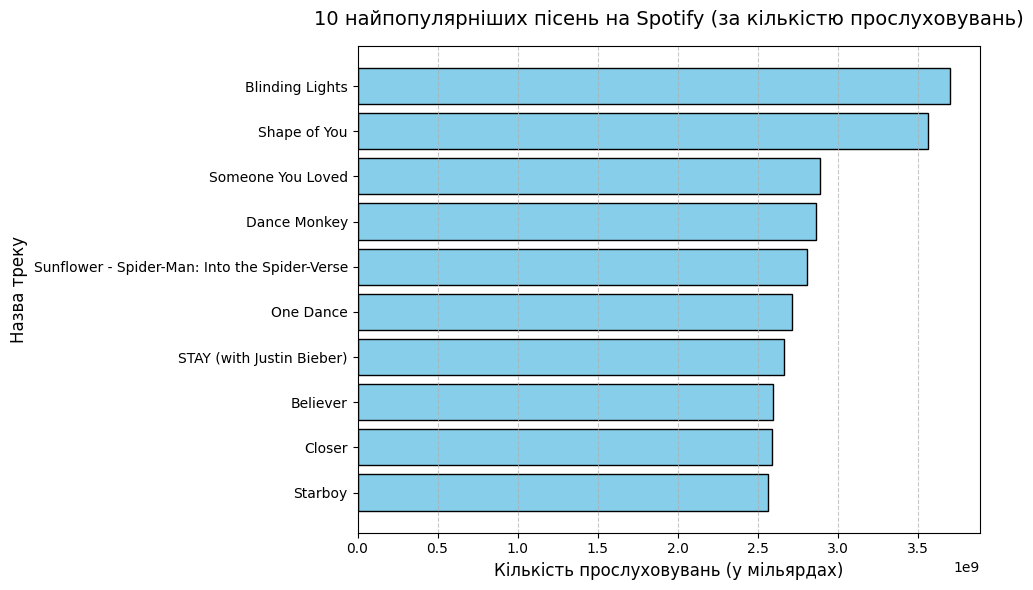

In [3]:
# Відбираємо 10 треків з найбільшою кількістю прослуховувань
top_10_songs = df.sort_values(by='streams', ascending=False).head(10)

plt.figure(figsize=(10, 6))
# Використовуємо [::-1] для того, щоб найпопулярніша пісня була зверху графіка
plt.barh(top_10_songs['track_name'][::-1], top_10_songs['streams'][::-1], color='skyblue', edgecolor='black')

plt.title('10 найпопулярніших пісень на Spotify (за кількістю прослуховувань)', fontsize=14, pad=15)
plt.xlabel('Кількість прослуховувань (у мільярдах)', fontsize=12)
plt.ylabel('Назва треку', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Завдання 2. Кругова діаграма: Розподіл жанрів

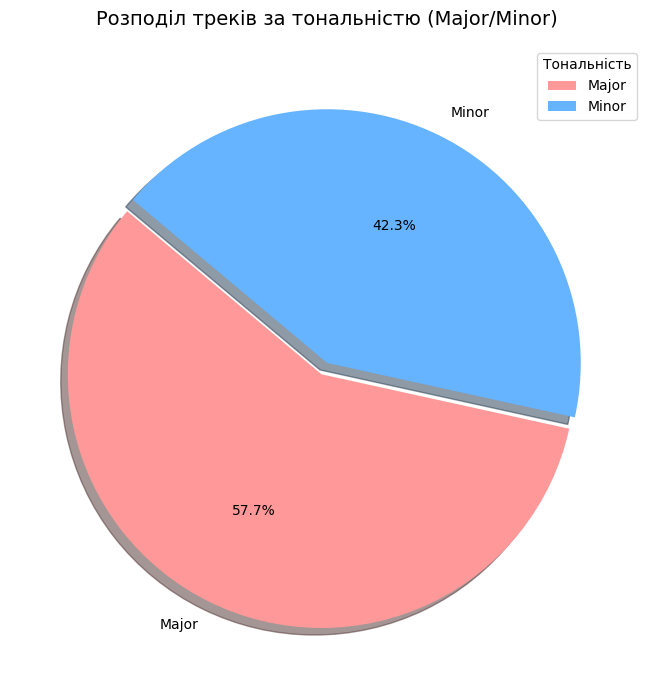

In [4]:
# Підрахунок кількості треків за тональністю (як заміна жанру)
mode_counts = df['mode'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(mode_counts.values, labels=mode_counts.index, autopct='%1.1f%%',
        startangle=140, colors=['#ff9999','#66b3ff'], explode=[0.05, 0], shadow=True)

plt.title('Розподіл треків за тональністю (Major/Minor)', fontsize=14, pad=15)
plt.legend(title='Тональність', loc='upper right')
plt.tight_layout()

plt.show()

Завдання 3. Динаміка популярності треку в залежності від часу

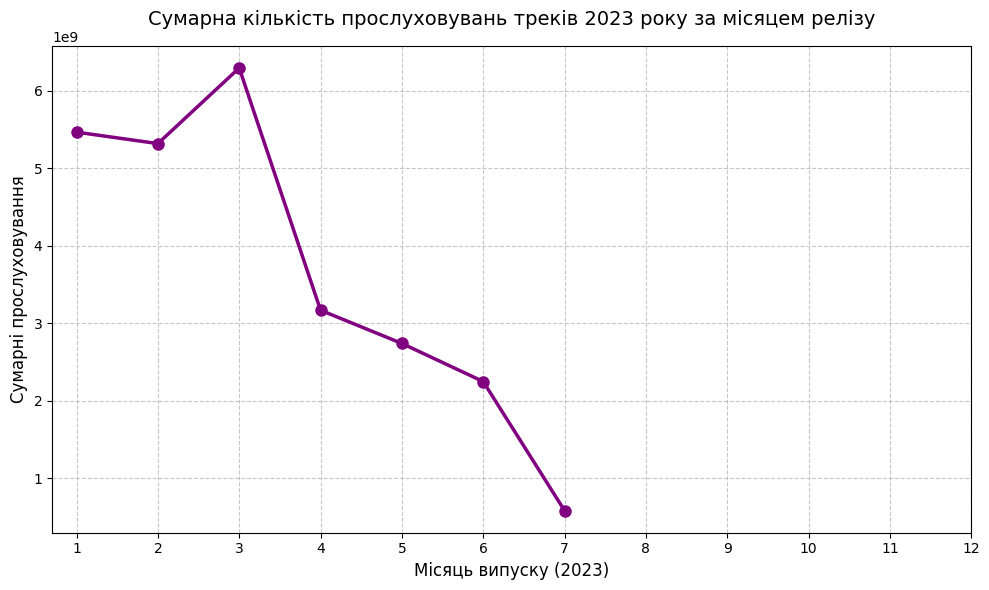

In [5]:
# Фільтруємо лише треки, випущені у 2023 році
df_2023 = df[df['released_year'] == 2023]

# Групуємо за місяцем релізу та рахуємо загальну кількість прослуховувань
monthly_streams = df_2023.groupby('released_month')['streams'].sum()

plt.figure(figsize=(10, 6))
plt.plot(monthly_streams.index, monthly_streams.values, marker='o', color='purple', linestyle='-', linewidth=2.5, markersize=8)

plt.title('Сумарна кількість прослуховувань треків 2023 року за місяцем релізу', fontsize=14, pad=15)
plt.xlabel('Місяць випуску (2023)', fontsize=12)
plt.ylabel('Сумарні прослуховування', fontsize=12)
plt.xticks(range(1, 13)) # Встановлюємо мітки для всіх 12 місяців
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Завдання 4. Рейтинг артистів на Spotify за кількістю слухачів (прослуховувань)

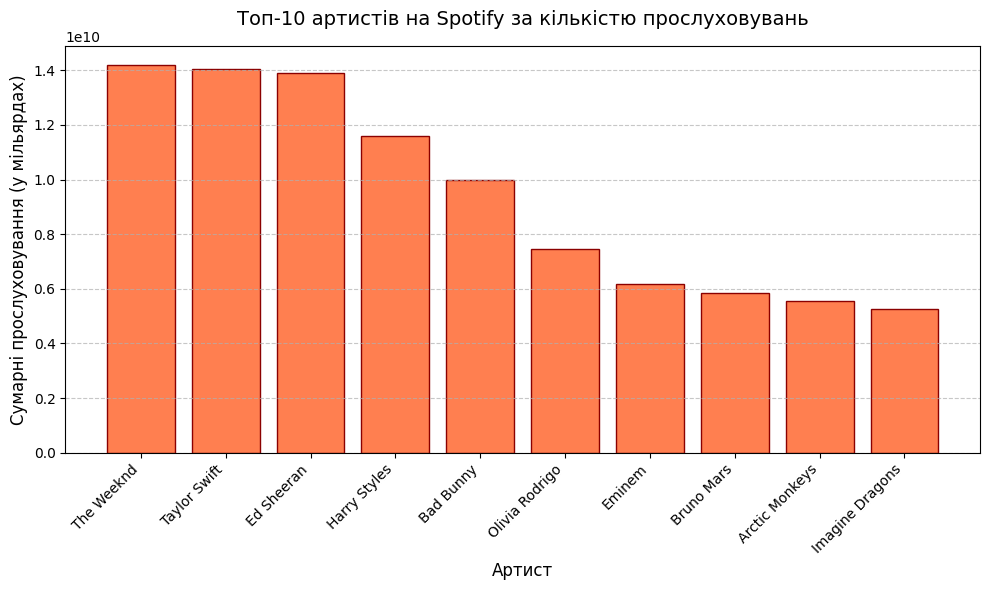

In [6]:
# Групуємо за артистом і знаходимо суму прослуховувань
top_10_artists = df.groupby('artist(s)_name')['streams'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.bar(top_10_artists.index, top_10_artists.values, color='coral', edgecolor='darkred')

plt.title('Топ-10 артистів на Spotify за кількістю прослуховувань', fontsize=14, pad=15)
plt.xlabel('Артист', fontsize=12)
plt.ylabel('Сумарні прослуховування (у мільярдах)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Повертаємо підписи осі X для кращої читабельності
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Завдання 5. Порівняння популярності трьох конкретних треків

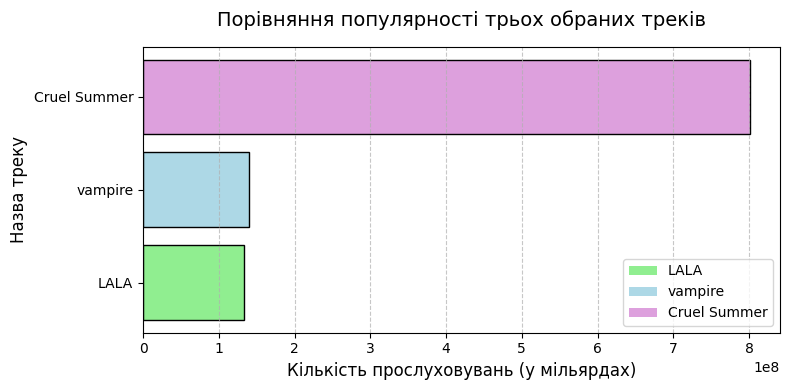

In [7]:
# Вибір трьох конкретних треків
tracks_to_compare = ['Cruel Summer', 'vampire', 'LALA']
df_compare = df[df['track_name'].isin(tracks_to_compare)].drop_duplicates(subset=['track_name'])

plt.figure(figsize=(8, 4))
colors = ['lightgreen', 'lightblue', 'plum']
bars = plt.barh(df_compare['track_name'], df_compare['streams'], color=colors, edgecolor='black')

plt.title('Порівняння популярності трьох обраних треків', fontsize=14, pad=15)
plt.xlabel('Кількість прослуховувань (у мільярдах)', fontsize=12)
plt.ylabel('Назва треку', fontsize=12)

# Додавання легенди
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=df_compare['track_name'].iloc[i]) for i in range(len(colors))]
plt.legend(handles=legend_elements, loc='lower right')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Висновок:
Під час виконання лабораторної роботи було практично закріплено навички візуалізації даних за допомогою бібліотеки Matplotlib у Python. На основі реального датасету "Spotify 2023" було побудовано та стилізовано різні типи діаграм (стовпчикові, кругові, лінійні), що дозволило наочно проаналізувати тренди, популярність окремих треків і виконавців, а також динаміку їхніх прослуховувань.